In [51]:
import pandas as pd 
import glob as glob
import os
import shutil
import matplotlib.pyplot as plt

In [36]:
os.chdir("/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis")

In [37]:
pdfs = glob.glob("data/datasets/reports_subset_from_full_data_3/PDFs_selected" + "/*.pdf")
txts_from = "data/datasets/reports_subset_from_full_data_3/TXTs_all"
txts_to = "data/datasets/reports_subset_from_full_data_3/TXTs" 

In [39]:
for pdf in pdfs: 
    name = os.path.basename(pdf)[:-3] + "txt"
    try: 
        shutil.copyfile(os.path.join(txts_from, name), os.path.join(txts_to, name))
    except FileNotFoundError: 
        continue

## Now adapt the overview

In [46]:
df = pd.read_csv("data/datasets/reports_subset_from_full_data_3/reports_subset_from_full_data_3_overview.csv", index_col=0)

In [47]:
pdf_names = [os.path.basename(pdf) for pdf in pdfs]
pdf_names

['Greek Organisation of Football Prognostics SA1.pdf',
 'D&L Industries, Inc.1.pdf',
 'HaiPhong Construction Joint Stock Corporation No33.pdf',
 'New Sparkle Roll International Group Limited1.pdf',
 'Olympique Lyonnais Groupe1.pdf',
 'Acea S.p.A.1.pdf',
 'Accenture Plc1.pdf',
 'Wenling Zhejiang Measuring & Cutting Tools Trading Centre Company Limited1.pdf',
 'Consolidated Water Co. Ltd.1.pdf',
 'Oriole Resources PLC1.pdf',
 'Adavale Resources Limited3.pdf',
 'Elektro Primorska d.d.3.pdf',
 'Budimex SA1.pdf',
 'Kahawatte Plantations PLC1.pdf',
 'Freightways Group Limited1.pdf',
 'Aurea SA1.pdf',
 'KCM Holdings Corp.1.pdf',
 'Safari Investments RSA Ltd.1.pdf',
 'Eco Recycling Limited3.pdf',
 'Alka Diamond Industries Limited1.pdf',
 'Lavastone Ltd.1.pdf',
 'URBAN LiKE INC.1.pdf',
 'Tantalizers PLC1.pdf',
 'Goodfood Market Corp.1.pdf',
 'Ellaktor SA1.pdf',
 'Save Foods, Inc.1.pdf',
 'MGM China Holdings Limited1.pdf',
 'EnviroSuite Ltd1.pdf',
 'GPP Resources Bhd.2.pdf',
 'USEN-NEXT HOLDINGS

In [48]:
df = df[df["Report"].apply(lambda x: x in pdf_names)]

In [52]:
df_grouped = df.groupby("NACE_Letter").count()

<BarContainer object of 18 artists>

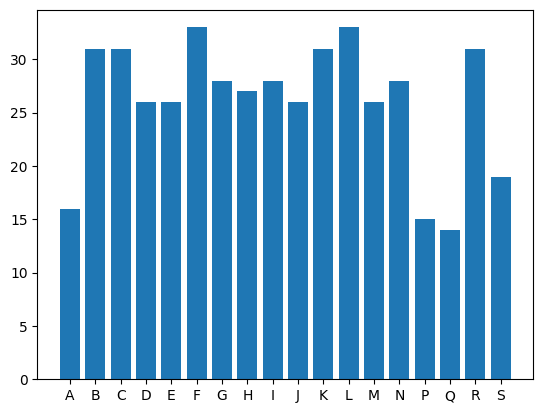

In [53]:
plt.bar(df_grouped.index, df_grouped["Symbol"])